In [682]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import keras
from keras import layers

Preprocess data:

In [683]:
df = pd.read_csv("iris.csv")

In [684]:
X_train = df.drop(columns="species")
y_train = df.drop (columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])

In [685]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [686]:
# One-hot encoding
y_train_onehot = pd.get_dummies(y_train)

Modeling:

In [687]:
num_classes = 3
# One-dimensional input vector of 4
input_shape = (4,)

In [688]:
inputs = keras.Input(shape=input_shape)
x = layers.Dense(64, activation="relu")(inputs)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="IRIS_FCN")
model.summary()

Model: "IRIS_FCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_58 (InputLayer)     │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515 (2.01 KB)

 Trainable params: 515 (2.01 KB)

 Non-trainable params: 0 (0.00 B)

In [689]:
model.compile(
    loss=keras.losses.CategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=0.005),
    metrics=["accuracy"],
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", # Monitors val_loss after every epoch
    patience=40, # If validation fails to improve after 40 epochs --> end
    restore_best_weights=True # Rolls back the epoch where fail occurred
)

history = model.fit(X_train, y_train_onehot, batch_size=20, epochs=500, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.2917 - loss: 1.1089 - val_accuracy: 0.0000e+00 - val_loss: 1.8034
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.8250 - loss: 0.8454 - val_accuracy: 0.0000e+00 - val_loss: 1.6850
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8333 - loss: 0.7154 - val_accuracy: 0.0000e+00 - val_loss: 1.5375
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8333 - loss: 0.6110 - val_accuracy: 0.0000e+00 - val_loss: 1.1073
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8333 - loss: 0.5337 - val_accuracy: 0.0000e+00 - val_loss: 1.1222
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8333 - loss: 0.4798 - val_accuracy: 0.0000e+00 - val_loss: 1.2140
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8333 - loss: 0.4312 - val_accuracy: 0.0000e+00 - val_loss: 0.8623
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8333 - loss: 0.4014 - val

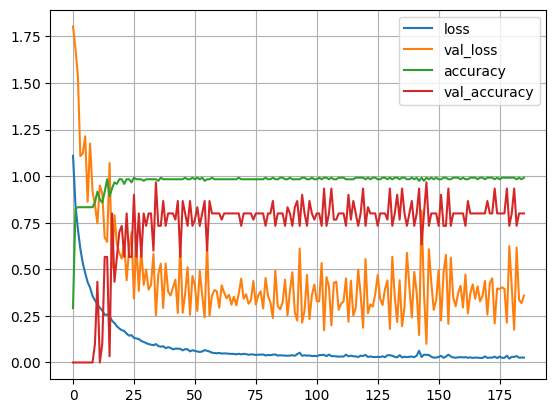

In [690]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.grid()
plt.legend(["loss", "val_loss", "accuracy", "val_accuracy"])
plt.show()

In [691]:
best_epoch = np.argmin(history.history['val_loss'])
best_val_acc = history.history['val_accuracy'][best_epoch]
best_training_acc = history.history['accuracy'][best_epoch]

print(f"Best training accuracy: {best_training_acc:.4f}")
print(f"Validation accuracy of best epoch: {best_val_acc:.4f}")

Best training accuracy: 0.9917
Validation accuracy of best epoch: 0.9667
